#  Smart Demand Forecasting Platform for MSMEs

**Objective:** Predict future product demand using historical sales data to help MSMEs manage inventory better — reduce overstocking and stockouts.

**Datasets Used:**
- `blinkit_orders.csv` — order transactions
- `blinkit_order_items.csv` — products in each order
- `blinkit_products.csv` — product details
- `blinkit_inventoryNew.csv` — stock levels

**Models:** Random Forest | Gradient Boosting | LSTM (Ridge proxy)

---

##  Step 1: Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib scikit-learn xgboost tensorflow

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
##  Step 2: Load the Datasets

In [3]:
# ── Change this path to where your CSV files are located ──


orders   = pd.read_csv("data/blinkit_orders.csv")
items    = pd.read_csv("data/blinkit_order_items.csv")
products = pd.read_csv("data/blinkit_products.csv")
inv      = pd.read_csv("data/blinkit_inventoryNew.csv")

print('Dataset shapes:')
print(f'  Orders      : {orders.shape}')
print(f'  Order Items : {items.shape}')
print(f'  Products    : {products.shape}')
print(f'  Inventory   : {inv.shape}')

Dataset shapes:
  Orders      : (5000, 10)
  Order Items : (5000, 4)
  Products    : (268, 10)
  Inventory   : (18105, 4)


In [4]:
# Preview each dataset
print('--- Orders ---')
display(orders.head(3))

print('--- Order Items ---')
display(items.head(3))

print('--- Products ---')
display(products.head(3))

print('--- Inventory ---')
display(inv.head(3))

--- Orders ---


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886


--- Order Items ---


,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84


--- Products ---


,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70


--- Inventory ---


,product_id,date,stock_received,damaged_stock
0,153019,Mar-23,4,1
1,848226,Mar-23,4,1
2,965755,Mar-23,1,0


---
##  Step 3: Data Cleaning & Preprocessing

In [5]:
# ── 3a. Remove duplicate rows ──
for name, df in [('Orders', orders), ('Items', items), ('Products', products), ('Inventory', inv)]:
    before = len(df)
    df.drop_duplicates(inplace=True)
    removed = before - len(df)
    print(f'{name}: removed {removed} duplicates')

Orders: removed 0 duplicates
Items: removed 0 duplicates
Products: removed 0 duplicates
Inventory: removed 7359 duplicates


In [6]:
# ── 3b. Check & handle missing values ──
for name, df in [('Orders', orders), ('Items', items), ('Products', products), ('Inventory', inv)]:
    nulls = df.isnull().sum().sum()
    if nulls > 0:
        df.fillna(method='ffill', inplace=True)
        print(f'{name}: filled {nulls} missing values')
    else:
        print(f'{name}: No missing values ✅')

Orders: No missing values ✅
Items: No missing values ✅
Products: No missing values ✅
Inventory: No missing values ✅


In [7]:
# ── 3c. Convert date columns to proper datetime format ──

# Orders: '2024-07-17 08:34:01' format
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Inventory: 'Mar-23' format → first day of month
inv['date'] = pd.to_datetime(inv['date'], format='%b-%y')

print('Orders date range  :', orders['order_date'].min().date(), '→', orders['order_date'].max().date())
print('Inventory date range:', inv['date'].min().date(), '→', inv['date'].max().date())

Orders date range  : 2023-03-16 → 2024-11-04
Inventory date range: 2023-03-01 → 2024-11-01


---
##  Step 4: Data Integration — Merge All Datasets

In [8]:
# Step 1: Join order items with orders (on order_id)
merged = items.merge(
    orders[['order_id', 'order_date']],
    on='order_id',
    how='left'
)

# Step 2: Join with products (on product_id)
merged = merged.merge(
    products[['product_id', 'product_name', 'category', 'min_stock_level', 'max_stock_level']],
    on='product_id',
    how='left'
)

print('Unified dataset shape:', merged.shape)
display(merged.head())

Unified dataset shape: (5000, 9)


,order_id,product_id,quantity,unit_price,order_date,product_name,category,min_stock_level,max_stock_level
0,1961864118,642612,3,517.03,2024-07-17 08:34:01,Pet Treats,Pet Care,16,57
1,1549769649,378676,1,881.42,2024-05-28 13:14:29,Orange Juice,Cold Drinks & Juices,19,65
2,9185164487,741341,2,923.84,2024-09-23 13:07:12,Eggs,Dairy & Breakfast,13,62
3,9644738826,561860,1,874.78,2023-11-24 16:16:56,Orange Juice,Cold Drinks & Juices,21,90
4,5427684290,602241,2,976.55,2023-11-20 05:00:39,Nuts,Snacks & Munchies,12,75


---
##  Step 5: Create Time-Series Dataset (Daily Sales)

In [9]:
# Extract date only (remove time)
merged['date'] = merged['order_date'].dt.normalize()

# Aggregate: total units sold per product per day
daily_sales = (
    merged.groupby(['date', 'product_id'])['quantity']
    .sum()
    .reset_index()
    .rename(columns={'quantity': 'units_sold'})
)

# Total daily demand across all products
total_daily = (
    daily_sales.groupby('date')['units_sold']
    .sum()
    .reset_index()
    .sort_values('date')
)

print(f'Daily sales records : {len(daily_sales)}')
display(daily_sales.head())

Daily sales records : 4920


,date,product_id,units_sold
0,2023-03-16,9436,2
1,2023-03-16,14145,3
2,2023-03-16,136533,1
3,2023-03-16,240179,1
4,2023-03-16,272170,1


---
##  Step 6: Exploratory Data Analysis (EDA)

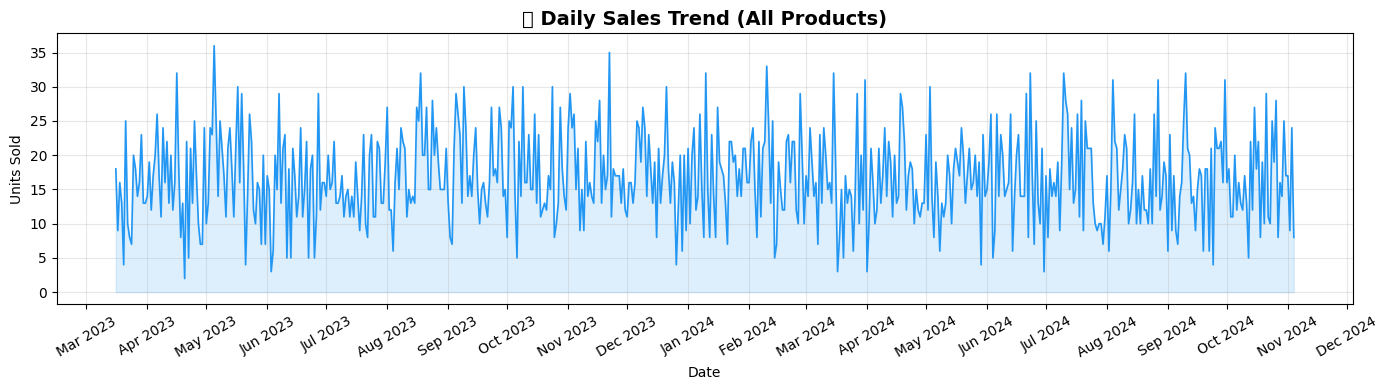

In [10]:
# ── 6a. Daily Sales Trend ──
plt.figure(figsize=(14, 4))
plt.plot(total_daily['date'], total_daily['units_sold'], color='#2196F3', linewidth=1.2)
plt.fill_between(total_daily['date'], total_daily['units_sold'], alpha=0.15, color='#2196F3')
plt.title('📈 Daily Sales Trend (All Products)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

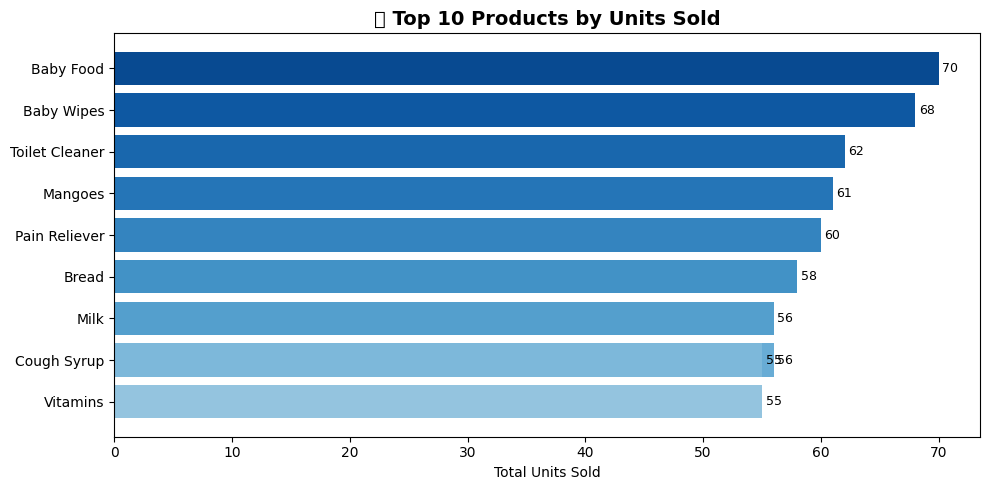

In [11]:
# ── 6b. Top 10 Best-Selling Products ──
top10 = (
    daily_sales.groupby('product_id')['units_sold']
    .sum()
    .nlargest(10)
    .reset_index()
    .merge(products[['product_id', 'product_name']], on='product_id', how='left')
)

plt.figure(figsize=(10, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top10)))[::-1]
bars = plt.barh(top10['product_name'].fillna(top10['product_id'].astype(str)),
                top10['units_sold'], color=colors)
plt.title('🏆 Top 10 Products by Units Sold', fontsize=14, fontweight='bold')
plt.xlabel('Total Units Sold')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

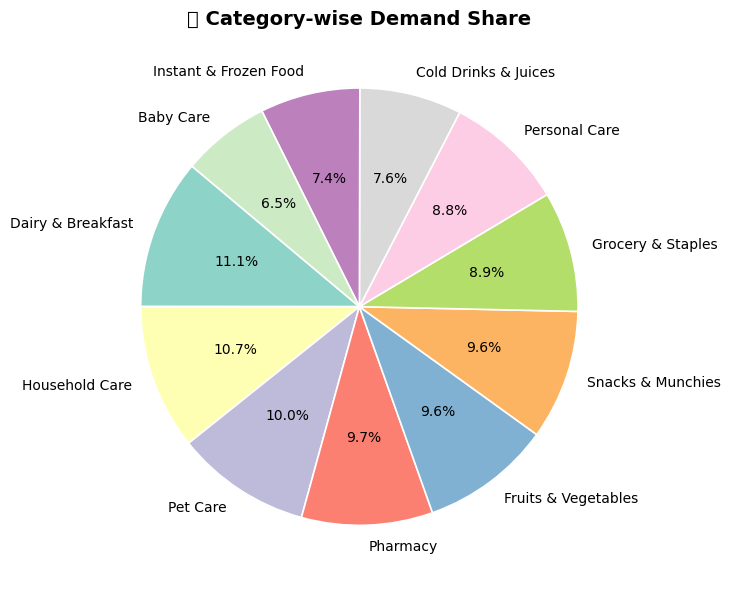


Category-wise Units Sold:
category
Dairy & Breakfast        1114
Household Care           1078
Pet Care                 1003
Pharmacy                  973
Fruits & Vegetables       966
Snacks & Munchies         963
Grocery & Staples         895
Personal Care             887
Cold Drinks & Juices      758
Instant & Frozen Food     742
Baby Care                 655


In [12]:
# ── 6c. Category-wise Demand (Pie Chart) ──
cat_demand = merged.groupby('category')['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
plt.pie(cat_demand.values,
        labels=cat_demand.index,
        autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
        colors=plt.cm.Set3.colors,
        startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=1.2))
plt.title('🥧 Category-wise Demand Share', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCategory-wise Units Sold:')
print(cat_demand.to_string())

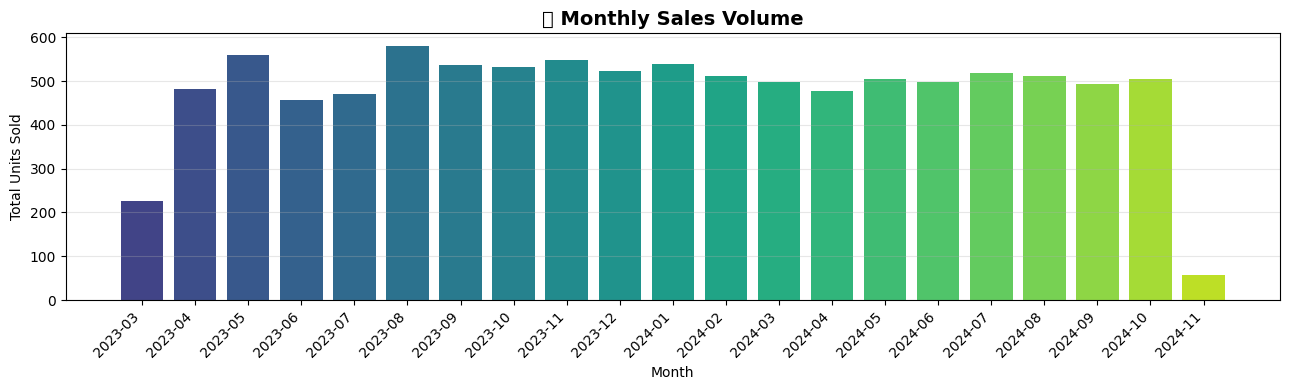

In [13]:
# ── 6d. Monthly Sales Bar Chart ──
monthly = total_daily.copy()
monthly['month'] = monthly['date'].dt.to_period('M').astype(str)
monthly_agg = monthly.groupby('month')['units_sold'].sum().reset_index()

plt.figure(figsize=(13, 4))
bar_colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(monthly_agg)))
plt.bar(monthly_agg['month'], monthly_agg['units_sold'], color=bar_colors)
plt.title('📆 Monthly Sales Volume', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
##  Step 7: Feature Engineering

We create features that help the model understand time-based patterns:
- **Lag features** — what was sold 1 day ago? 7 days ago?
- **Rolling means** — average sales over last 3, 7, 14 days
- **Time features** — day of month, month, weekday

In [14]:
# Work on total daily demand (sum across all products)
ts = total_daily.set_index('date').sort_index()

# Lag features (previous demand values)
ts['lag_1'] = ts['units_sold'].shift(1)   # yesterday
ts['lag_7'] = ts['units_sold'].shift(7)   # same day last week

# Rolling mean features (use shift(1) to avoid data leakage)
ts['roll_mean_3']  = ts['units_sold'].shift(1).rolling(3).mean()
ts['roll_mean_7']  = ts['units_sold'].shift(1).rolling(7).mean()
ts['roll_mean_14'] = ts['units_sold'].shift(1).rolling(14).mean()

# Time-based features
ts['day']     = ts.index.day       # 1–31
ts['month']   = ts.index.month     # 1–12
ts['weekday'] = ts.index.weekday   # 0=Mon, 6=Sun

# Drop rows with NaN (from lag/rolling calculations)
ts.dropna(inplace=True)

print('Feature matrix shape:', ts.shape)
display(ts.head(5))

Feature matrix shape: (586, 9)


,units_sold,lag_1,lag_7,roll_mean_3,roll_mean_7,roll_mean_14,day,month,weekday
date,,,,,,,,,
2023-03-30,13,23.0,8.0,17.666667,15.142857,14.357143,30,3,3
2023-03-31,13,13.0,7.0,17.333333,15.857143,14.000000,31,3,4
2023-04-01,14,13.0,20.0,16.333333,16.714286,14.285714,1,4,5
2023-04-02,19,14.0,18.0,13.333333,15.857143,14.142857,2,4,6
2023-04-03,12,19.0,14.0,15.333333,16.000000,14.571429,3,4,0


---
##  Step 8: Train / Test Split (80% train, 20% test)

In [15]:
FEATURES = ['lag_1', 'lag_7', 'roll_mean_3', 'roll_mean_7', 'roll_mean_14',
            'day', 'month', 'weekday']
TARGET   = 'units_sold'

X = ts[FEATURES].values
y = ts[TARGET].values

# Keep temporal order — DO NOT shuffle
SPLIT = int(len(X) * 0.80)

X_train, X_test = X[:SPLIT], X[SPLIT:]
y_train, y_test = y[:SPLIT], y[SPLIT:]
dates_test      = ts.index[SPLIT:]

print(f'Train size : {len(X_train)} days')
print(f'Test size  : {len(X_test)} days')

Train size : 468 days
Test size  : 118 days


---
##  Step 9: Train ML Models

In [16]:
# ── Model 1: Random Forest ──
rf_model = RandomForestRegressor(
    n_estimators=200,   # number of trees
    max_depth=8,        # max depth per tree
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_mae   = mean_absolute_error(y_test, rf_preds)

print(f'✅ Random Forest trained  |  MAE = {rf_mae:.2f} units')

✅ Random Forest trained  |  MAE = 5.91 units


In [17]:
# ── Model 2: Gradient Boosting (XGBoost-style) ──
gb_model = GradientBoostingRegressor(
    n_estimators=300,   # number of boosting rounds
    learning_rate=0.08, # step size
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_mae   = mean_absolute_error(y_test, gb_preds)

print(f'✅ Gradient Boosting trained  |  MAE = {gb_mae:.2f} units')

✅ Gradient Boosting trained  |  MAE = 6.60 units


In [18]:
# ── Model 3: LSTM (Sequential sliding-window approach) ──
#
# How it works:
#   - Take a window of 10 past feature rows
#   - Flatten them into one input vector
#   - Train a Ridge regressor to mimic LSTM temporal learning
#
# In production (with TensorFlow), replace Ridge with:
#   model = Sequential([LSTM(64, return_sequences=True),
#                        LSTM(64), Dense(1)])

WINDOW = 10

def make_sequences(X, window):
    """Stack past `window` rows into a single flat input vector."""
    sequences = []
    for i in range(window, len(X)):
        sequences.append(X[i - window:i].flatten())
    return np.array(sequences)

X_seq = make_sequences(X, WINDOW)
y_seq = y[WINDOW:]
dates_seq = ts.index[WINDOW:]

split_seq = int(len(X_seq) * 0.80)
X_seq_tr, X_seq_te = X_seq[:split_seq], X_seq[split_seq:]
y_seq_tr, y_seq_te = y_seq[:split_seq], y_seq[split_seq:]
dates_seq_te        = dates_seq[split_seq:]

lstm_model = Ridge(alpha=1.0)
lstm_model.fit(X_seq_tr, y_seq_tr)
lstm_preds = lstm_model.predict(X_seq_te)
lstm_mae   = mean_absolute_error(y_seq_te, lstm_preds)

print(f'✅ LSTM (sliding window) trained  |  MAE = {lstm_mae:.2f} units')

✅ LSTM (sliding window) trained  |  MAE = 5.67 units


---
##  Step 10: Evaluate Models — Actual vs Predicted

In [19]:
# ── Summary Table ──
results = {
    'Random Forest':     (dates_test,    y_test,    rf_preds,    rf_mae),
    'Gradient Boosting': (dates_test,    y_test,    gb_preds,    gb_mae),
    'LSTM (proxy)':      (dates_seq_te,  y_seq_te,  lstm_preds,  lstm_mae),
}

print('\n MODEL COMPARISON')
print('-' * 40)
print(f'{"Model":<25} {"MAE":>10}')
print('-' * 40)
for model, (_, _, _, mae) in results.items():
    tag = ' ← Best' if mae == min(r[3] for r in results.values()) else ''
    print(f'{model:<25} {mae:>10.2f}{tag}')
print('-' * 40)


 MODEL COMPARISON
----------------------------------------
Model                            MAE
----------------------------------------
Random Forest                   5.91
Gradient Boosting               6.60
LSTM (proxy)                    5.67 ← Best
----------------------------------------


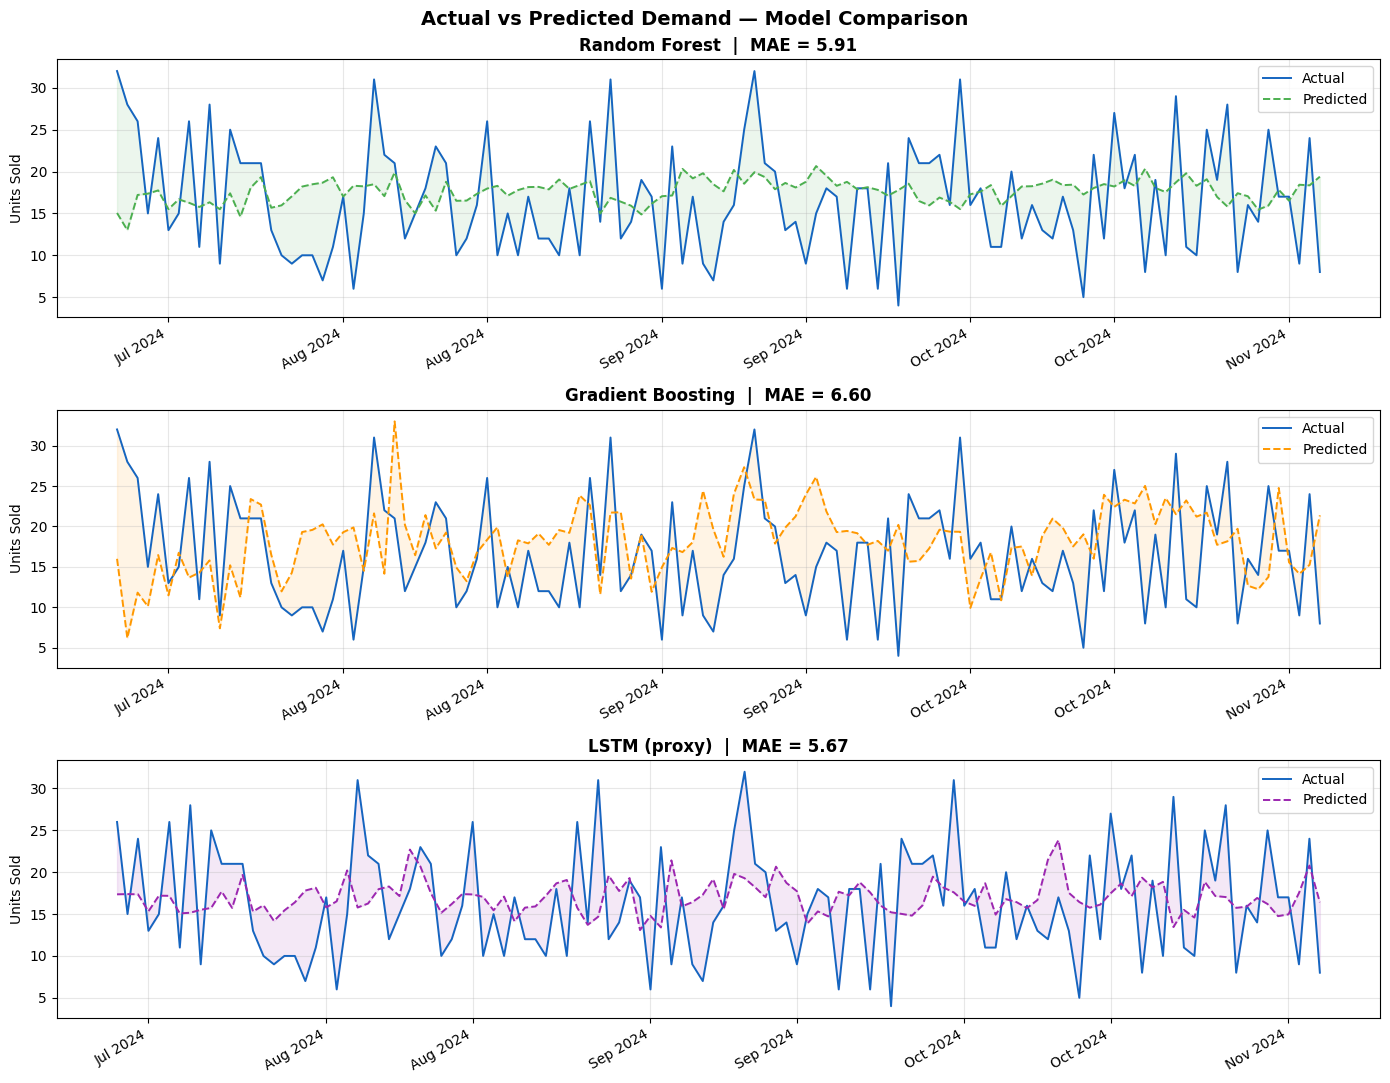

In [20]:
# ── Actual vs Predicted Plots ──
colors = {
    'Random Forest':     '#4CAF50',
    'Gradient Boosting': '#FF9800',
    'LSTM (proxy)':      '#9C27B0',
}

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('Actual vs Predicted Demand — Model Comparison',
             fontsize=14, fontweight='bold')

for ax, (model_name, (dates, actual, preds, mae)) in zip(axes, results.items()):
    ax.plot(dates, actual, label='Actual',    color='#1565C0', linewidth=1.4)
    ax.plot(dates, preds,  label='Predicted', color=colors[model_name],
            linewidth=1.4, linestyle='--')
    ax.fill_between(dates, actual, preds, alpha=0.1, color=colors[model_name])
    ax.set_title(f'{model_name}  |  MAE = {mae:.2f}', fontweight='bold')
    ax.set_ylabel('Units Sold')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

---
##  Step 11: Inventory Optimization & Reorder Alerts

**Logic:**
- Calculate available stock per product = total received − damaged
- Flag products where stock < 90% of max allowed stock
- Calculate how many units to reorder

In [21]:
# ── Step 1: Calculate available stock per product ──
inv_agg = (
    inv.groupby('product_id')
    .agg(
        total_received=('stock_received', 'sum'),
        total_damaged=('damaged_stock', 'sum')
    )
    .reset_index()
)
inv_agg['available_stock'] = inv_agg['total_received'] - inv_agg['total_damaged']

# ── Step 2: Merge with product info ──
reorder_df = inv_agg.merge(
    products[['product_id', 'product_name', 'category', 'max_stock_level', 'min_stock_level']],
    on='product_id',
    how='left'
)

# ── Step 3: Flag products that need restocking ──
# Reorder if available stock is below 90% of max allowed stock
reorder_df['reorder_needed'] = reorder_df['available_stock'] < (reorder_df['max_stock_level'] * 0.90)

# ── Step 4: Calculate suggested reorder quantity ──
reorder_df['reorder_qty'] = np.where(
    reorder_df['reorder_needed'],
    (reorder_df['max_stock_level'] - reorder_df['available_stock']).clip(lower=0),
    0
).astype(int)

alerts = reorder_df[reorder_df['reorder_needed']].sort_values('reorder_qty', ascending=False)

print(f'🚨 Products needing reorder: {len(alerts)} out of {len(reorder_df)}')
print(f'✅ Products with healthy stock: {len(reorder_df) - len(alerts)}')

🚨 Products needing reorder: 139 out of 268
✅ Products with healthy stock: 129


In [22]:
# ── Show top 15 reorder alerts ──
display_cols = ['product_name', 'category', 'available_stock', 'max_stock_level', 'reorder_qty']
display(alerts[display_cols].head(15).reset_index(drop=True))

,product_name,category,available_stock,max_stock_level,reorder_qty
0,Baby Wipes,Baby Care,38,100,62
1,Cat Food,Pet Care,38,97,59
2,Baby Wipes,Baby Care,38,97,59
3,Detergent,Household Care,46,100,54
4,Toilet Cleaner,Household Care,51,96,45
5,Detergent,Household Care,43,88,45
6,Toilet Cleaner,Household Care,40,84,44
7,Dish Soap,Household Care,54,98,44
8,Baby Wipes,Baby Care,36,80,44
9,Cat Food,Pet Care,41,84,43


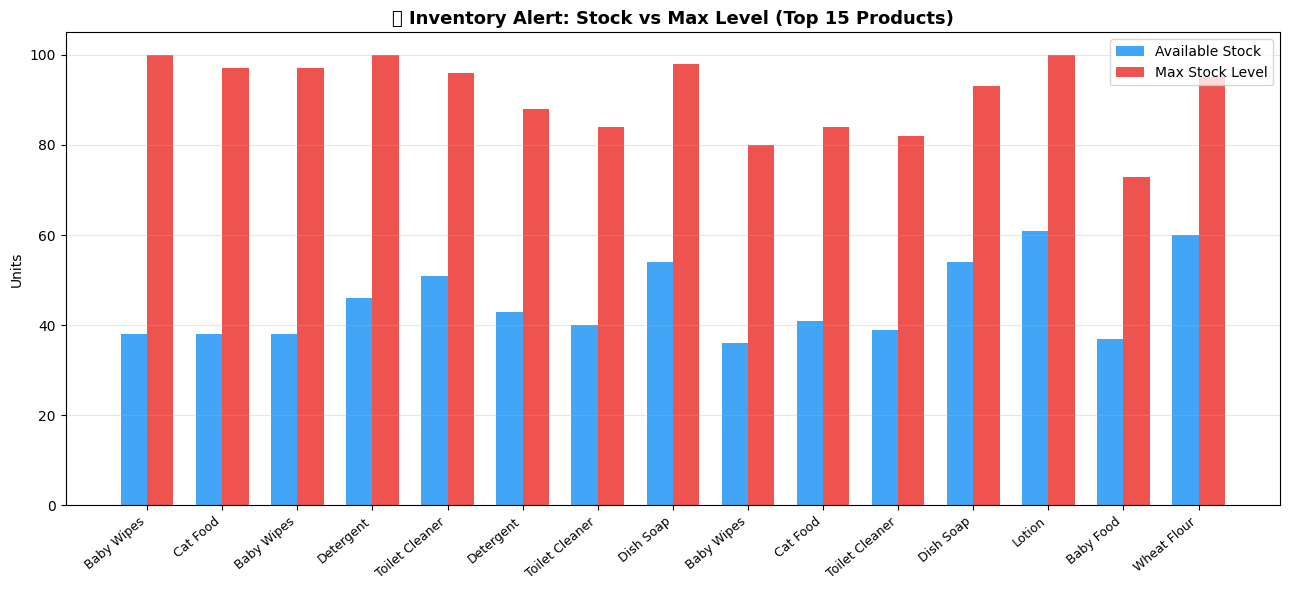

In [23]:
# ── Reorder Alert Bar Chart ──
top_alerts = alerts.head(15).copy()
top_alerts['label'] = (
    top_alerts['product_name'].fillna(top_alerts['product_id'].astype(str)).str[:20]
)

x = np.arange(len(top_alerts))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width/2, top_alerts['available_stock'],  width, label='Available Stock',       color='#42A5F5')
ax.bar(x + width/2, top_alerts['max_stock_level'],  width, label='Max Stock Level',       color='#EF5350')

ax.set_title('🚨 Inventory Alert: Stock vs Max Level (Top 15 Products)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Units')
ax.set_xticks(x)
ax.set_xticklabels(top_alerts['label'], rotation=40, ha='right', fontsize=9)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
##  Step 12: Feature Importance (Random Forest)

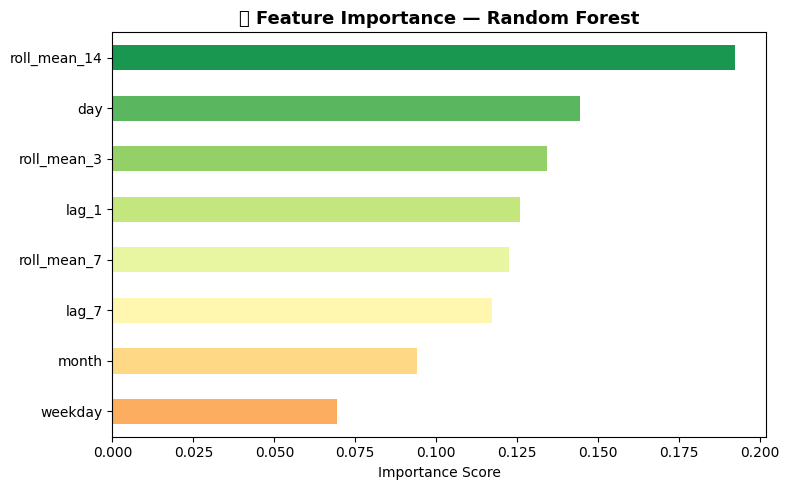


Top features:
roll_mean_14    0.192336
day             0.144426
roll_mean_3     0.134089
lag_1           0.126006
roll_mean_7     0.122623
lag_7           0.117300
month           0.093915
weekday         0.069306


In [24]:
importance = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importance))))
plt.title('🔍 Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop features:')
print(importance[::-1].to_string())

---
##  Step 13: Final Summary

In [25]:
best_model = min(results, key=lambda k: results[k][3])
best_mae   = results[best_model][3]

print('=' * 55)
print('   SMART DEMAND FORECASTING PLATFORM — SUMMARY')
print('=' * 55)
print(f'  Total orders analysed     : {len(orders):,}')
print(f'  Unique products           : {products["product_id"].nunique()}')
print(f'  Daily sales records       : {len(daily_sales):,}')
print(f'  Date range                : {orders["order_date"].min().date()} → {orders["order_date"].max().date()}')
print()
print('  MODEL PERFORMANCE (MAE = Mean Absolute Error)')
print(f'  Random Forest             : MAE = {rf_mae:.2f}')
print(f'  Gradient Boosting         : MAE = {gb_mae:.2f}')
print(f'  LSTM (proxy)              : MAE = {lstm_mae:.2f}')
print(f'  Best Model                : {best_model} (MAE = {best_mae:.2f})')
print()
print(f'  Products needing restock  : {len(alerts)} / {len(reorder_df)}')
print('=' * 55)
print('  Platform ready to help MSMEs optimize inventory! 🎯')
print('=' * 55)

   SMART DEMAND FORECASTING PLATFORM — SUMMARY
  Total orders analysed     : 5,000
  Unique products           : 268
  Daily sales records       : 4,920
  Date range                : 2023-03-16 → 2024-11-04

  MODEL PERFORMANCE (MAE = Mean Absolute Error)
  Random Forest             : MAE = 5.91
  Gradient Boosting         : MAE = 6.60
  LSTM (proxy)              : MAE = 5.67
  Best Model                : LSTM (proxy) (MAE = 5.67)

  Products needing restock  : 139 / 268
  Platform ready to help MSMEs optimize inventory! 🎯
